<img src="imgs/unifor_logo.png" width="400">
<br>
<b>
<font size="6" face="arial" color="blue">
    Graduação em Ciência da Computação
</font>
</b>
<br
<b>
<font size="4" face="arial">
    Disciplina: Métodos Quantitativos para Computação
</font>
</b>

**Orientador: Prof. Me. Ricardo Carubbi** <br>
*Docente da Graduação e Pós-Graduação em Ciência de Dados e Inteligência Artificial*<br>
*Laboratório de Ciência de Dados e Inteligência Artificial*<br>
*Universidade de Fortaleza*<br>

<p dir="ltr" style="text-align: left;">
    <strong>Links:</strong>
    <a href="https://www2.unifor.br/controle_pesquisa/pesquisarprofessor.do?actionParameter=prepareUpdate&amp;p_tp_ambiente=2&amp;p_tp_chamada=1&amp;p_tp_apresentacao=1&amp;cdPesquisador=767686193" target="_blank">Unifor</a|
    <a href="http://lattes.cnpq.br/5738786447903616" target="_blank">Lattes</a|
    <a href="https://unifor.br/web/pesquisa-inovacao/ncdia" target="_blank">NCDIA</a|
    <a href="https://github.com/carubbi/" target="_blank">Github</a>
</p>

# Variáveis Aleatórias Discretas e Suas Distribuições de Probabilidade

Uma **variável aleatória** é uma variável cujo valor **depende do acaso**; portanto, seu valor está **associado a uma probabilidade**.

Uma **variável aleatória discreta** é uma variável aleatória cujos possíveis valores podem ser **enumerados** (isto é, podem ser listados um a um).

Uma **distribuição de probabilidade** é uma listagem dos possíveis valores e das **probabilidades correspondentes** de uma variável aleatória discreta — muitas vezes representada por uma **fórmula matemática** (Weiss, 2010).

## Distribuição de Variáveis Aleatórias Discretas

Um **gráfico da distribuição de probabilidade**, que mostra a probabilidade de cada valor representado por uma **barra vertical** (cuja altura é igual à probabilidade) e os possíveis valores da variável aleatória discreta no **eixo horizontal**, é chamado de **histograma de probabilidade** ou **histograma de proporções**.

A soma das probabilidades de uma variável aleatória discreta $X$ é sempre igual a 1:

$$
\sum_{i=1}^{N} P(X = x_i) = 1 \tag{1}
$$

Em um **grande número de observações independentes** de uma variável aleatória $X$,  
o histograma de probabilidade **aproxima-se** da distribuição de probabilidade teórica de $X$ (Weiss, 2010).

### Vídeo: O que é uma distribuição estatística?

Assista ao vídeo explicativo sobre a **Distribuição Binomial** no link abaixo:

🎬 [Clique aqui para assistir no YouTube](https://youtu.be/oI3hZJqXJuc?si=N-y6ayu-hLQ2IkP8)

<img src="imgs/statquest_dist_estatistica.png" width="640">

### Exemplo

Vamos elaborar o conceito de variáveis aleatórias discretas por meio de um exercício.

Suponha que nossa população em estudo consista de todos os estudantes, todos os professores e todos os membros do corpo administrativo da UNIFOR. Escolhemos aleatoriamente um desses indivíduos e perguntamos a ele/ela sobre o número de irmãos.

Consequentemente, a resposta — o número de irmãos de um indivíduo selecionado aleatoriamente — é uma **variável aleatória discreta**, denotada por $X$.

O valor real (número de irmãos) de $X$ depende do acaso, mas ainda assim podemos listar todos os valores possíveis de $X$, por exemplo: 0 irmão, 1 irmão, 2 irmãos e assim por diante.

Para fins de simplificação, limitamos o número de irmãos neste exercício a 5.

In [194]:
# Primeiro, vamos importar todas as bibliotecas necessárias.
import numpy as np
import random, math
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

De acordo com o site da **Unifor**, há **25.000 estudantes**, **1.200 doutorandos**, **1.300 professores** e **1.000 funcionários** associados à Unifor.

In [195]:
fu_studs = 25000
fu_PhD = 1200
fu_profs = 1300
fu_staff = 1000

### Dados de Entrada Utilizados

- População Unifor: estudantes = 25.000, doutorandos = 1.200, professores = 1.300, funcionários = 1.000.
- Probabilidades do número de irmãos (0 a 5): [0.2, 0.425, 0.275, 0.07, 0.025, 0.005].
- Tamanhos amostrais simulados: 10, 100, 1.000 e 100.000 (quando indicado).
- Experimentos com dado justo: faces 1–6, probabilidade 1/6 cada.
- Parâmetros binomiais: n = 25, p = 0.3, com x em {3, 9, 15} conforme o contexto.
- Parâmetros de Poisson: λ = 1 (exemplo teórico), λ = 2,5 e λ = 7 (simulações gráficas).


In [196]:
experiment_prob = np.array([0.2, 0.425, 0.275, 0.07, 0.025, 0.005])


def siblings(x):
    return random.choices(np.array([0, 1, 2, 3, 4, 5]), weights=experiment_prob, k=x)

Como nós não temos **nenhuma ideia da probabilidade associada** a um **número específico de irmãos**, nós começamos alguns **experimentos**:

1. Nós escolhemos **um indivíduo aleatoriamente** e perguntamos o **número de irmãos**. A resposta é:

In [197]:
siblings(1)

[np.int64(0)]

2. Escolhemos **dez indivíduos aleatoriamente** e perguntamos a eles sobre o **número de irmãos**.  
As respostas são:

In [198]:
for s in siblings(10):
    print(s, end=" ")

5 0 2 3 1 0 3 2 2 3 

3. Escolhemos **100 indivíduos** e perguntamos a eles sobre o **número de irmãos**.  
As respostas são:

In [199]:
for s in siblings(100):
    print(s, end=" ")

2 1 2 1 1 0 1 1 2 2 1 2 2 0 1 4 0 0 1 2 0 2 2 2 1 1 0 1 0 0 1 4 1 1 1 1 0 0 0 1 1 2 0 1 1 1 3 2 0 2 2 2 2 1 0 1 3 3 1 2 1 2 2 2 2 2 0 0 2 2 0 2 1 1 1 2 1 1 2 2 1 3 1 1 0 2 0 1 0 1 2 2 0 1 1 0 2 1 1 2 

Como se observa, a notação se torna **bastante confusa** quando aumentamos o **número de indivíduos entrevistados**.  

Assim, decidimos **registrar a frequência** e a **frequência relativa correspondente** dos valores dados para as classes **0, 1, 2, 3, 4, 5** (para ser explícito: a última classe corresponde a **exatamente 5 irmãos**), e apresentar o experimento na forma de uma **tabela**.

Selecionamos **1.000 indivíduos** e perguntamos a eles sobre o **número de irmãos**.

A forma mais simples será construir um **objeto `pd.Series`** para poder aplicar a função **`value_counts`** da biblioteca *pandas*.  

Essa função permite definir o argumento **`normalize = True`** para obter as **frequências relativas**.


In [200]:
random.seed(1000)
experiment = pd.Series(siblings(1000))

siblings1000_f = experiment.value_counts()
siblings1000_p = experiment.value_counts(normalize=True)

siblings1000 = pd.DataFrame({
    "siblings (x)": siblings1000_f.index,
    "Frequência (f)": siblings1000_f,
    "Freq. Relativa (f)": siblings1000_p})

siblings1000.sort_index()

,siblings (x),Frequência (f),Freq. Relativa (f)
0,0,185,0.185
1,1,420,0.420
2,2,289,0.289
3,3,64,0.064
4,4,35,0.035
5,5,7,0.007


Depois de listarmos **todos os valores possíveis** e calcularmos as **frequências relativas correspondentes**, ainda **não sabemos exatamente** as **probabilidades da variável aleatória discreta** $X$ para toda a **população de 28.500 indivíduos** associada à **Unifor**.  

No entanto, depois de conversar com **1.000 indivíduos escolhidos aleatoriamente**, estamos **bastante confiantes** de que um **número tão grande de entrevistas** — comparado ao tamanho da população total (28.500) — nos dará uma **boa aproximação das probabilidades** da variável aleatória discreta $X$ (número de irmãos) para toda a população.

Na próxima etapa, desenhamos um **histograma de proporções** (da amostra), que mostra os **valores possíveis de uma variável aleatória discreta** $X$ no **eixo horizontal** e as **proporções desses valores** no **eixo vertical**.  

Um **histograma de proporções** também pode servir como uma **aproximação da distribuição de probabilidade**.  

Observe que a **soma das probabilidades**, bem como a **soma das proporções** de qualquer variável aleatória discreta, é igual a **1**.

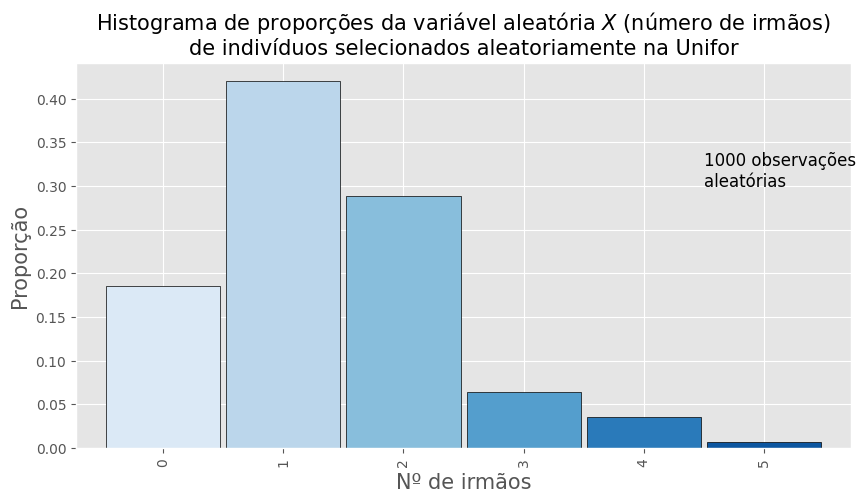

In [201]:
# Paleta de cores e gráfico de barras (tradução e adaptação para Unifor)
col_map = plt.get_cmap("Blues", 8)
siblings1000_p.sort_index().plot(
    kind="bar",
    figsize=(10, 5),
    color=col_map([1, 2, 3, 4, 5, 6]),
    align="center",
    width=0.95,
    edgecolor="black",
)

plt.title(
    "Histograma de proporções da variável aleatória $X$ (número de irmãos)\n"
    "de indivíduos selecionados aleatoriamente na Unifor",
    fontsize=15,
)
plt.xlabel("Nº de irmãos", fontsize=15)
plt.ylabel("Proporção", fontsize=15)
plt.text(4.5, 0.3, "1000 observações\naleatórias", fontsize=12)

plt.show()

**Fig. 1 - Histograma de proporções da variável número de irmãos em 1000 observações simuladas.** A figura apresenta a distribuição proporcional do número de irmãos observado em uma amostra aleatória de tamanho 1000. As barras indicam quais valores de número de irmãos são mais frequentes na amostra e permitem comparar a distribuição amostral com a ideia de distribuição de probabilidade discreta. Fonte: Carubbi, 2026.

Em muitas aplicações da vida real, **nós não conhecemos a distribuição de probabilidade da população** — e provavelmente **nunca conheceremos**.  
Isso ocorre principalmente porque, em muitos casos, a **população é muito grande**, ou **não há como obter dados confiáveis**, ou ainda **não dispomos de recursos financeiros nem de tempo** para uma coleta de dados exaustiva.

No entanto, ao **aumentar o número de observações independentes** de uma variável aleatória $X$, o **histograma de proporções da amostra** se **aproximará cada vez mais** do **histograma de probabilidade da população inteira**.

Para demonstrar essa afirmação, **ampliamos nosso experimento**:

Selecionamos sequencialmente **10, 100 e 1.000 indivíduos aleatórios** associados à **Unifor** e perguntamos a eles sobre o **número de irmãos**.  

Vamos **representar graficamente** cada um dos três experimentos e, por fim, **compará-los** à **distribuição de probabilidade real**.

Observação: este é um **exemplo didático simplificado** e **não representa o número real de irmãos** na população de indivíduos da Unifor.

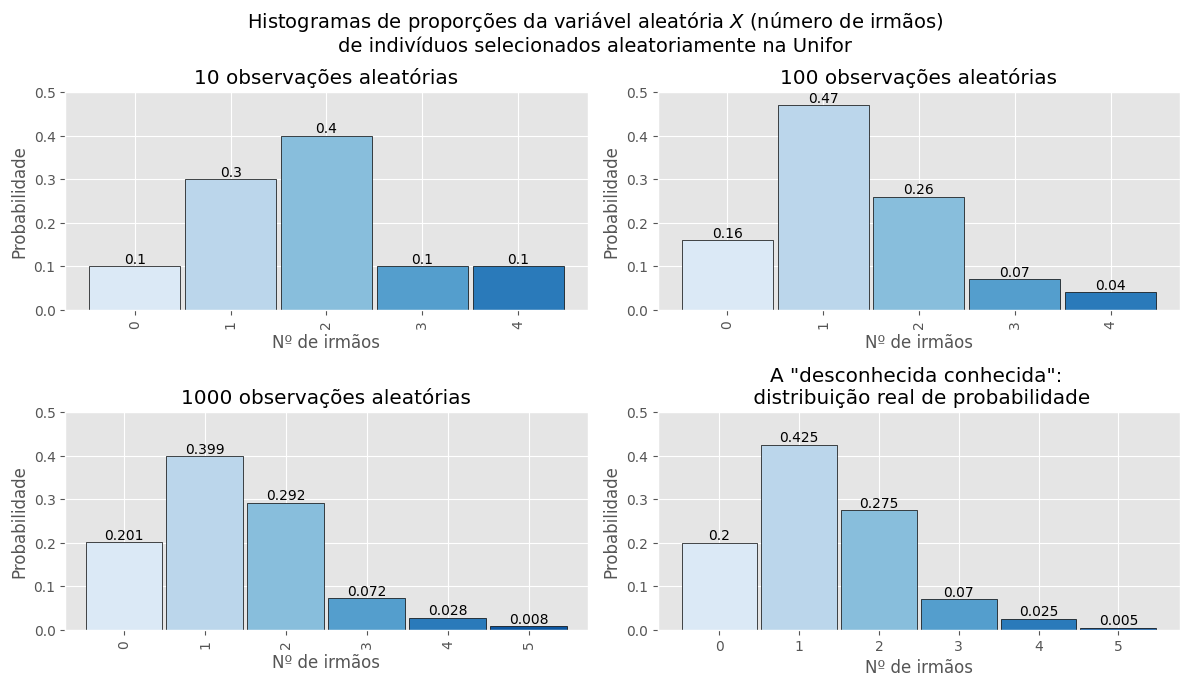

In [202]:
# Amostras e criação dos subgráficos
samples = list([10, 100, 1000])

fig, ax = plt.subplots(2, 2, figsize=(12, 7))
col_pal = plt.get_cmap("Blues", len(siblings1000_p))

# Título principal do conjunto de gráficos
fig.suptitle(
    "Histogramas de proporções da variável aleatória $X$ (número de irmãos)\n"
    "de indivíduos selecionados aleatoriamente na Unifor",
    fontsize=14,
    y=0.975,
)

# Títulos de cada gráfico
ax[0, 0].set_title("10 observações aleatórias")
ax[0, 1].set_title("100 observações aleatórias")
ax[1, 0].set_title("1000 observações aleatórias")
ax[1, 1].set_title('A "desconhecida conhecida": \n distribuição real de probabilidade')
ax[1, 1].set_xlabel("Nº de irmãos")
ax[1, 1].set_ylabel("Probabilidade")
ax[1, 1].set_ylim(0, 0.5)

# Gráfico com a distribuição real conhecida
ax[1, 1].bar(
    np.array([0, 1, 2, 3, 4, 5]),
    experiment_prob,
    color=col_map([1, 2, 3, 4, 5, 6]),
    align="center",
    width=0.95,
    edgecolor="black",
)
for bars in ax[1, 1].containers:
    ax[1, 1].bar_label(bars)

# Gráficos para as amostras de 10, 100 e 1000 indivíduos
for sample, ax in zip(samples, ax.ravel()):
    siblings_p = pd.Series(siblings(sample)).value_counts(normalize=True).sort_index()
    siblings_p.plot(
        kind="bar",
        color=col_map([1, 2, 3, 4, 5, 6]),
        align="center",
        width=0.95,
        edgecolor="black",
        ax=ax,
    )
    ax.set_xlabel("Nº de irmãos")
    ax.set_ylabel("Probabilidade")
    ax.set_ylim(0, 0.5)
    for bars in ax.containers:
        ax.bar_label(bars)

plt.tight_layout()
plt.show()

**Fig. 2 - Comparação entre histogramas de proporções amostrais e distribuição real do número de irmãos.** A figura apresenta histogramas de proporções para amostras de diferentes tamanhos e, no último painel, a distribuição real de probabilidade. O aumento do tamanho amostral reduz oscilações aleatórias e aproxima a distribuição observada da distribuição de probabilidade populacional. Fonte: Carubbi, 2026.

### Média de uma Variável Aleatória Discreta

A **média** de uma variável aleatória discreta $X$ é denotada por $\mu_X$ ou, quando não há risco de confusão, simplesmente por $\mu$.  
Os termos **valor esperado**, **$E(X)$** e **esperança matemática** são comumente usados no lugar do termo média.

A média (ou valor esperado) é dada por:

$$
E(X) = \sum_{i=1}^{N} x_i \, P(X = x_i) \tag{2}
$$

Em um **grande número de observações independentes** de uma variável aleatória $X$, a **média amostral** das observações tende a se aproximar do valor esperado $E(X)$, isto é, da média populacional $\mu$.  

Quanto **maior o número de observações**, mais estável tende a ser essa aproximação (Weiss, 2010).


In [203]:
# Exibir valores possíveis do experimento e suas respectivas probabilidades
siblings1000_p.sort_index()

0    0.185
1    0.420
2    0.289
3    0.064
4    0.035
5    0.007
Name: proportion, dtype: float64

Vamos calcular o **valor esperado (média)** para este experimento.

$$
E(X) = \sum_{i=1}^{N} x_i \, P(X = x_i)
      = 0 \cdot P(X = 0)
      + 1 \cdot P(X = 1)
      + 2 \cdot P(X = 2)
      + 3 \cdot P(X = 3)
      + 4 \cdot P(X = 4)
      + 5 \cdot P(X = 5) \tag{3}
$$

Substituindo os valores observados da amostra:

$$
E(X) = 0 \cdot 0.185
      + 1 \cdot 0.420
      + 2 \cdot 0.289
      + 3 \cdot 0.064
      + 4 \cdot 0.035
      + 5 \cdot 0.007
      = 1.365 \tag{4}
$$

In [204]:
# Cálculo em Python
np.sum(siblings1000_p.index * siblings1000_p.values)

np.float64(1.365)

### Exercício

Vamos considerar um **dado justo de seis faces**.  
Podemos facilmente calcular o **valor esperado** $E(X)$ usando Python.  

O termo *justo* significa que cada valor da variável aleatória  
$X = x_i$, com $x \in \{1, 2, 3, 4, 5, 6\}$, é **igualmente provável**.  
Portanto, $P(X = x_i) = \frac{1}{6}$.

$$
E(X) = \sum_{i=1}^{6} x_i \, P(X = x_i)
     = 1 \cdot \frac{1}{6}
     + 2 \cdot \frac{1}{6}
     + 3 \cdot \frac{1}{6}
     + 4 \cdot \frac{1}{6}
     + 5 \cdot \frac{1}{6}
     + 6 \cdot \frac{1}{6}
     = 3.5 \tag{5}
$$

Em Python, escrevemos o seguinte código:


In [205]:
# Valor esperado de um dado justo de seis faces
p_die = 1 / 6                 # Probabilidade de cada face
die = np.arange(1, 7)         # Valores possíveis: 1, 2, 3, 4, 5, 6
np.sum(die * p_die)           # Cálculo do valor esperado (E[X])

np.float64(3.5)

**Interpretação do Valor Esperado (E(X))**
>
O valor esperado representa a média teórica de uma variável aleatória ao longo de muitas repetições do experimento.  
Ele não precisa coincidir com um valor observável em uma única realização.
>
No caso de um dado justo, embora não seja possível obter 3,5 em um lançamento, esse valor indica o ponto de equilíbrio para o qual a média dos resultados converge à medida que o número de lançamentos aumenta.
>
Portanto, $E(X)$ deve ser interpretado como uma medida de tendência central de longo prazo.

No entanto, e se **não tivermos certeza** de que o dado é realmente **justo**? Como saber se **não estamos sendo enganados**? Ou, em outras palavras: **quantas vezes precisamos lançar o dado** antes de podermos estar **mais confiantes**?

Vamos realizar um **experimento computacional**: Sabemos, a partir do raciocínio anterior, que o **valor esperado** de um dado justo de 6 faces é **3.5**.  

Conduziremos um experimento **lançando o dado repetidas vezes**. Armazenamos o resultado e, antes de lançar o dado novamente, calculamos a **média de todos os lançamentos até o momento**.  

Para realizar esse pequeno experimento, escreveremos um **loop `for` em Python**.

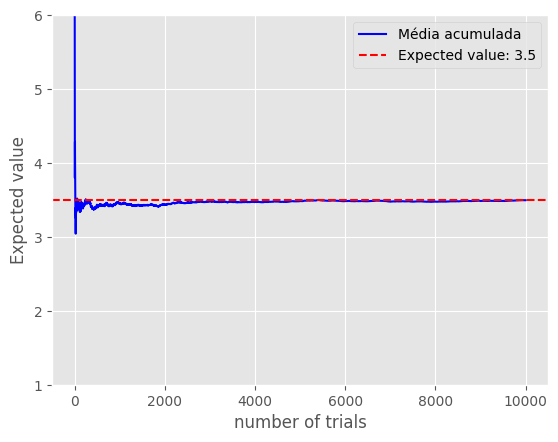

In [206]:
### Simulação ###
eyes = np.arange(1, 7)                     # eventos possíveis (faces do dado)
probs = [1 / len(eyes)] * len(eyes)        # probabilidades iguais para cada face
expected_value = np.round(np.sum(eyes * probs), 2)  # cálculo do valor esperado (E[X])
n = 10000                                  # número máximo de lançamentos
values = []                                # vetor vazio para armazenar os resultados dos lançamentos
averages = []                              # vetor vazio para armazenar as médias acumuladas até o momento

for roll in range(1, n):
    values.append(random.choices(eyes, weights=probs, k=1))
    averages.append(np.mean(values))

plt.plot(averages, color="blue", label="Média acumulada")
plt.xlabel("number of trials")
plt.ylabel("Expected value")

plt.ylim((1, 6))

plt.axhline(y=3.5, color="r", linestyle="--", label=f"Expected value: {expected_value}")
plt.legend()
plt.show()

**Fig. 3 - Convergência da média acumulada em lançamentos de dado.** A figura mostra a trajetória da média acumulada dos resultados simulados em função do número de ensaios, com linha de referência no valor esperado teórico. À medida que o número de ensaios aumenta, a média acumulada tende a se estabilizar próxima do valor esperado, ilustrando a regularidade de longo prazo. Fonte: Carubbi, 2026.

O gráfico mostra que, após um comportamento inicial **volátil**, a **curva se estabiliza** e **se aproxima** do valor esperado $E(X) = 3.5$.


### Desvio Padrão de uma Variável Aleatória Discreta

O **desvio padrão** de uma variável aleatória discreta $X$ é denotado por $\sigma_X$ ou, quando não houver possibilidade de confusão, simplesmente por $\sigma$.  

Ele é definido como:

$$
\sigma = \sqrt{ \sum_{i=1}^{N} (x_i - \mu)^2 \, P(X = x_i) } \tag{6}
$$


In [207]:
# Cálculo da distribuição de probabilidade a partir dos resultados da simulação
x = pd.Series(np.arange(1, 7))

p_x = pd.Series(values).value_counts(normalize=True)
p_x.sort_index()

[1]    0.169217
[2]    0.165117
[3]    0.165917
[4]    0.163216
[5]    0.173217
[6]    0.163316
Name: proportion, dtype: float64

In [208]:
# Cálculo do desvio padrão usando a fórmula da variância para uma variável aleatória discreta
sd = np.sqrt(np.sum((x - np.mean(values)) ** 2 * p_x.values))
sd

np.float64(1.7127210348841206)

## A Distribuição Binomial

Muitas aplicações de **probabilidade** e **estatística** envolvem a **repetição de um experimento**.  
Chamamos cada repetição de um **ensaio** (*trial*), e estamos particularmente interessados nos casos em que o experimento (cada ensaio) tem apenas **dois possíveis resultados**`: **sucesso ou fracasso**, **verdadeiro ou falso**, **0 ou 1**.

Para analisar **ensaios repetidos** de um experimento que possui **dois possíveis resultados**, precisamos conhecer os conceitos de **fatorial**, **coeficientes binomiais** e **ensaios de Bernoulli**.

Com base nesses pré-requisitos, estudaremos a **distribuição binomial**, que é uma **distribuição de probabilidade** para o **número de sucessos** em uma sequência de **ensaios de Bernoulli** (Weiss, 2010).




### Pré-requisitos  
#### Fatoriais

O **produto dos primeiros** $k$ **números inteiros positivos** (números naturais) é chamado de **fatorial de $k$** e é denotado por $k!$ (Weiss, 2010).

$$
k! = k \times (k - 1) \times \dots \times 2 \times 1 \tag{7}
$$

Também definimos que:

$$
0! = 1 \tag{8}
$$

Vamos considerar um **exemplo simples** e calcular o **fatorial de 6**.  
Substituindo na equação acima, temos:

$$
6! = 6 \times 5 \times 4 \times 3 \times 2 \times 1 \tag{9}
$$

Em Python, escrevemos:

In [209]:
# Cálculo do fatorial de 6
math.factorial(6)

720

#### Coeficientes Binomiais

Se $n$ é um **inteiro positivo** e $k$ é um **inteiro não negativo** menor ou igual a $n$, então o **coeficiente binomial** $\binom{n}{k}$ é definido como:

$$
\binom{n}{k} = \frac{n!}{k! \, (n - k)!} \tag{10}
$$

O coeficiente binomial $\binom{n}{k}$ é frequentemente lido como **combinação de n elementos tomados k a k**, porque existem exatamente $\binom{n}{k}$ **maneiras de escolher $k$ elementos**, **sem considerar a ordem**, de um conjunto com $n$ elementos.  

Em outras palavras, o coeficiente binomial **refere-se ao número de combinações** de $n$ objetos tomados $k$ de cada vez **sem repetição**. Observe que **a ordem de seleção não importa**.

#### Exemplo ilustrativo

Considere uma palavra simples, como **“dog”**, que contém três letras diferentes: **d, o, g**.  

Quantas possibilidades existem para escolher **exatamente uma letra** dentre as três?  
Há 3 possibilidades: “d”, “o” ou “g”.  
Assim, podemos escrever essa combinação como $\binom{3}{1}$.

Agora, e se quisermos **duas letras**?  
Quantas combinações existem para escolher **exatamente duas letras** dentre as três?  
As combinações são: “do”, “dg” e “og”.  

Observe que “og” e “go” contam **como uma única combinação**, pois a **ordem não importa**.

Portanto, o número de combinações é **3**, o que podemos escrever como $\binom{3}{2}$.

Por fim, quantas combinações existem para escolher **três letras** dentre as três?  
Vamos pedir ajuda ao **Python**!

Primeiro, implementamos uma abordagem simples, aplicando a fórmula acima:

In [210]:
n = 3  # a palavra "dog" tem 3 letras
k = 2  # escolhemos exatamente duas letras

# Cálculo do número de combinações usando a fórmula 
math.factorial(n) / (math.factorial(k) * (math.factorial(n - k)))

3.0

No entanto, também podemos usar a função **`comb()`** do módulo **`math`** para calcular o número de combinações.

In [211]:
n = 3

# Cálculo do número de combinações usando a função comb do módulo math
math.comb(n, 1), math.comb(n, 2), math.comb(n, 3)

(3, 3, 1)

Agora que estamos familiarizados com o conceito, vamos considerar um exemplo mais complexo:  
O **Centro de Ciências Tecnológicas da Unifor** pede a todos os formandos em **Ciência da Computação** que escolham suas **4 disciplinas favoritas** da grade curricular.  

Quantas respostas diferentes os estudantes poderiam dar, se o currículo oferecesse **48 disciplinas obrigatórias** para escolha?  
Algum palpite? Vamos perguntar ao **Python**.

In [212]:
n = 48
k = 4
math.comb(n, k)

194580

Os estudantes poderiam dar **194.580 respostas diferentes**.


### Ensaios de Bernoulli

Repetições de um experimento são chamadas de **ensaios de Bernoulli** se as três condições a seguir forem satisfeitas:

1. O experimento (cada ensaio) possui **dois possíveis resultados**, denotados por $s$ para **sucesso** e $f$ para **fracasso**.  
2. Os ensaios são **independentes**.  
3. A **probabilidade de sucesso** é a probabilidade de que um experimento resulte em um resultado classificado como “sucesso”, simplesmente chamada de **probabilidade de sucesso** e denotada por $p$, **permanece a mesma** de um ensaio para outro.

Em probabilidade, “sucesso” **não significa algo bom ou desejável**.
>
O termo é apenas uma **convenção** para indicar o evento de interesse em um experimento aleatório.
>
Assim, “sucesso” pode representar qualquer resultado que queremos analisar, como:
>
- obter “cara” em uma moeda;
- ocorrer falha em um sistema;
- um cliente cancelar um serviço.
>
Portanto, **sucesso = evento de interesse**, independentemente de ser positivo ou negativo no contexto real.

### Definição

A **distribuição binomial** é a **distribuição de probabilidade** para o **número de sucessos** em uma sequência de **ensaios de Bernoulli** (Weiss, 2010).

### Fórmula da Probabilidade Binomial

Em $n$ ensaios de Bernoulli, o número de resultados que contêm exatamente $x$ sucessos é igual ao **coeficiente binomial** $\binom{n}{x}$ (Weiss, 2010).

Seja $x$ o **número total de sucessos** em $n$ ensaios de Bernoulli, com **probabilidade de sucesso** $p$.  
Então, a **distribuição de probabilidade** da variável aleatória $X$ é dada por:

$$
P(X = x) = \binom{n}{x} \, p^x \, (1 - p)^{n - x},
\quad x = 0, 1, 2, \dots, n. \tag{11}
$$

A variável aleatória $X$ é chamada de **variável aleatória binomial** e diz-se que ela segue uma **distribuição binomial** com parâmetros $n$ e $p$ (Weiss, 2010).

A fórmula ($11$) representa a probabilidade de obter exatamente $x$ sucessos em $n$ ensaios independentes, em que cada ensaio tem probabilidade de sucesso $p$.
>
A fórmula combina dois elementos:
>
- $\binom{n}{x}$: número de sequências possíveis com exatamente $x$ sucessos em $n$ ensaios;
- $p^x$: probabilidade de ocorrerem $x$ sucessos;
- $(1 - p)^{n - x}$: probabilidade de ocorrerem $n - x$ fracassos.
>
Assim, a probabilidade total é obtida multiplicando o número de sequências possíveis pela probabilidade de cada sequência.
>
**Interpretação**: soma das probabilidades de todas as formas possíveis de ocorrerem exatamente $x$ sucessos e, portanto, $n - x$ fracassos.

### Exemplo rápido

Em 3 lançamentos de moeda justa ($n = 3$, $p = 0{,}5$), qual a probabilidade de obter exatamente $x = 2$ caras?

**Sequências possíveis**: CCK, CKC, KCC.

Cada sequência tem probabilidade:
$$
(0,5)^2 (1-0,5)^1 = 0,125 \tag{12}
$$

Como existem $\binom{3}{2} = 3$ sequências:

$$
P(X = 2) = 3 \times 0,125 = 0,375 \tag{13}
$$

### Vídeo: Distribuição Binomial

Assista ao vídeo explicativo sobre a **Distribuição Binomial** no link abaixo:

🎬 [Clique aqui para assistir no YouTube](https://youtu.be/J8jNoF-K8E8?si=h4x2fxoXEluSxpvP)

<img src="imgs/statquest_dist_binomial.png" width="640">

### Aplicações

Vamos considerar um **exemplo do mundo real**.

Estatísticas de longo prazo indicam que a **probabilidade de aprovação** na **prova final de métodos quantitativos** é de **0,3**.  
Sim, aproximadamente **70% dos estudantes reprovam** na disciplina!  

Vamos considerar uma **turma com $n_0$ estudantes**.  
Qual é a **probabilidade de que exatamente $x_1$ estudantes** dessa turma sejam aprovados no exame final de estatística?  
De forma mais formal, queremos calcular:

$$
P(X = 3) \tag{14}
$$

Mais uma vez, começaremos implementando uma **abordagem simples em Python**.

In [213]:
def binomial_prob(n, x, p):
    """Calcula a probabilidade binomial P(X = x) para n ensaios e probabilidade de sucesso p."""
    return math.comb(n, x) * p**x * (1 - p)**(n - x)


n = 25  # número de estudantes
p = 0.3  # probabilidade de sucesso (aprovação)
k = 3    # exatamente 3 estudantes serão aprovados

print(f"P(X = {k}) = {binomial_prob(n, k, p):.4f}")

P(X = 3) = 0.0243


Uau! A **probabilidade** de que exatamente $x_1$ de $n_0$ estudantes ($P(X = 3)$) **sejam aprovados** em métodos quantitativos é **bastante baixa**.  

E quanto à **probabilidade** de que exatamente $x_2$ de $n_0$ estudantes ($P(X = 15)$) **sejam aprovados** em métodos quantitativos?  

Vamos verificar isso com o **Python**.


In [214]:
n = 25
p = 0.3
k = 15

print(f"P(X = {k}) = {binomial_prob(n, k, p):.4f}")

P(X = 15) = 0.0013


A probabilidade de $P(X = 15)$ é aproximadamente **0,1%**.  
Podemos continuar nossos experimentos para descobrir todas as **probabilidades de exatamente um resultado** para $k = 0, 1, 2, \dots, n$.  

### Função de Massa de Probabilidade (PMF) e Função de Distribuição Acumulada (CDF)

A **função de massa de probabilidade** (*Probability Mass Function*, **PMF**) calcula probabilidades **pontuais**, como $P(X = k)$: a probabilidade de observar exatamente um valor específico da variável aleatória discreta.  
A **função de distribuição acumulada** (*Cumulative Distribution Function*, **CDF**) calcula probabilidades **acumuladas**, como $P(X \leq k)$: a probabilidade de observar um valor até determinado limite.

Observe que, neste exemplo específico, **não é muito informativo** saber a probabilidade de exatamente um número $k$ de estudantes serem aprovados no exame. É **mais interessante** saber qual é a **probabilidade de que $k$ ou menos estudantes** ($P(X \leq k)$) sejam aprovados no exame, ou, de forma igualmente relevante, qual é a **probabilidade de que $k$ ou mais estudantes** ($P(X \geq k)$) sejam aprovados no exame.  

Como exercício, vamos usar o **Python** para determinar a **probabilidade de que 9 ou menos estudantes sejam aprovados** na prova final de estatística, ou seja, $P(X \leq 9)$.  

Estamos interessados na probabilidade de que **0, ou 1, ou 2, ..., até 9 estudantes** sejam aprovados no exame.  

Para calcular essa probabilidade, podemos **estender nossa abordagem simples** e somar:

$$
P(X = 0) + P(X = 1) + P(X = 2) + \dots + P(X = 9) \tag{15}
$$

In [215]:
n = 25 # número de estudantes
p = 0.3 # probabilidade de sucesso (aprovação)
k = 9 # número máximo de estudantes sejam aprovados

def binomial_cdf(n, k, p):
    cdf = 0
    for i in range(k + 1):
        cdf += binomial_prob(n, i, p)
    return cdf

print(f"P(X ≤ {k}) = {binomial_cdf(n, k, p):.4f}")

P(X ≤ 9) = 0.8106


A probabilidade de que 9 ou menos estudantes sejam aprovados no exame de estatística  
($P(X \leq 9)$) é de 81,1%. Consequentemente, a probabilidade de que 10 ou mais estudantes sejam aprovados no exame é  
$P(X \geq 10) = 1 - P(X \leq 9)$, isto é, 18,9%.

Além do resultado pouco favorável nas estatísticas de aprovação no exame final, a implementação acima é bastante manual.  

Por isso, utilizaremos a distribuição **`binom`**, disponível no módulo **`scipy.stats`**.  

A distribuição **`binom`** recebe **n** e **p** como parâmetros, em que **n** representa o número de ensaios e **p** representa a probabilidade de sucesso em cada ensaio. Use **`help()`** para consultar mais informações.

De acordo com a documentação, o método pode ser usado da seguinte forma:  

**`binom.pmf(k, n, p)`**, em que **k** corresponde ao valor observado, **n** ao número de ensaios e **p** à probabilidade de sucesso em cada ensaio. A função possui outros argumentos opcionais, mas eles não serão necessários neste notebook.  

Há vários métodos associados à distribuição **`binom`**. Por exemplo, o método **`pmf`** calcula a função de massa de probabilidade.  

Para mais informações sobre os diferentes métodos, consulte **`help()`**.

Para verificar se **`binom.pmf()`** funciona como esperado, retomamos os exemplos anteriores: $P(X = 3)$ e $P(X = 15)$.

In [216]:
n = 25 # número de estudantes
p = 0.3 # probabilidade de sucesso (aprovação)
k = [3, 15] # exatamente 3 e 15 estudantes serão aprovados

for i in k:
    print(f"P(X = {i}) = {binomial_prob(n, i, p):.4f}")

P(X = 3) = 0.0243
P(X = 15) = 0.0013


Compare esses resultados com os obtidos pela implementação manual apresentada anteriormente. Os valores devem coincidir.

A função **`binom.pmf()`** é útil para calcular probabilidades pontuais, como $P(X = x)$. Para probabilidades acumuladas, como $P(X \leq x)$, podemos calcular várias probabilidades pontuais e somá-las, ou usar diretamente a função de distribuição acumulada. Para a cauda direita, usa-se o complemento apropriado, como $P(X > x) = 1 - P(X \leq x)$.  

Vamos considerar o exemplo anterior ($P(X \leq 9)$).

A figura abaixo mostra as probabilidades pontuais $P(X = k)$ para cada valor de $k$. A probabilidade acumulada $P(X \leq 9)$ é obtida somando as barras de $k = 0$ até $k = 9$.

In [217]:
n = 25  # número de estudantes
p = 0.3  # probabilidade de sucesso (aprovação)
k = np.arange(0, 10) # valores de k de 0 a 9

pmf = stats.binom.pmf(k, n, p)
cdf = np.sum(pmf)

resultado = pd.DataFrame({
    "k": k,
    "P(X = k)": pmf,
})

display(resultado)
print("P(X <= 9) = soma de P(X = k), para k = 0, 1, ..., 9")
print(f"P(X <= 9) = {cdf:.4f} ({cdf:.1%})")

,k,P(X = k)
0,0,0.000134
1,1,0.001437
2,2,0.007390
3,3,0.024280
4,4,0.057231
5,5,0.103017
6,6,0.147166
7,7,0.171194
8,8,0.165080
9,9,0.133636


P(X <= 9) = soma de P(X = k), para k = 0, 1, ..., 9
P(X <= 9) = 0.8106 (81.1%)


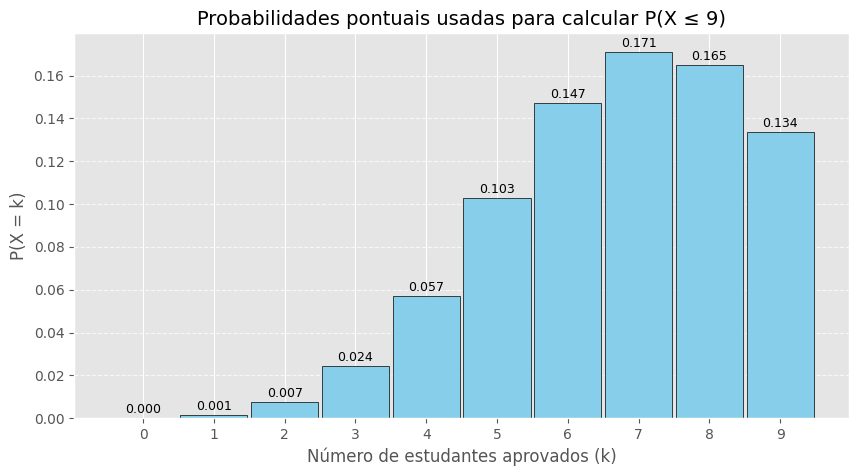

In [218]:
# Figura e gráfico de barras
plt.figure(figsize=(10, 5))
plt.bar(k, pmf, width=0.95, color="skyblue", edgecolor="black")

# Rótulos de cada barra
for i, val in enumerate(pmf):
    plt.text(k[i], val + 0.001, f"{val:.3f}", ha="center", va="bottom", fontsize=9)

# Título e rótulos dos eixos
plt.title("Probabilidades pontuais usadas para calcular P(X ≤ 9)", fontsize=14)
plt.xlabel("Número de estudantes aprovados (k)", fontsize=12)
plt.ylabel("P(X = k)", fontsize=12)
plt.xticks(k)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

**Fig. 4 - Probabilidades pontuais usadas no cálculo de $P(X \leq 9)$.** A figura apresenta as probabilidades $P(X = k)$ para $k = 0, 1, 2, \dots, 9$ em uma variável aleatória binomial com $n = 25$ e $p = 0{,}3$. A probabilidade acumulada $P(X \leq 9)$ é obtida pela soma das barras mostradas no gráfico. Fonte: Carubbi, 2026.

Outra função apropriada para calcular $P(X \leq 9)$ é **`binom.cdf()`**, que calcula a **função de distribuição acumulada**. Nesse caso, o resultado corresponde à probabilidade de observar um número de sucessos **menor ou igual a m**.  

A função **`cdf`** é prática porque dispensa a soma manual das probabilidades pontuais.  

O uso de **`binom.cdf()`** é o seguinte: `binom.cdf(m, N, p)`.

**Nota:** ao calcular probabilidades acumuladas pela **cauda esquerda**, o **Python** retorna, por padrão, $P(X \leq x)$. Para calcular a **cauda direita**, é necessário usar o complemento adequado, como `1 - binom.cdf(x, n, p)`, que corresponde a $P(X > x)$.

Para deixar claro, vamos recalcular $P(X \leq 9)$. O resultado do cálculo anterior foi **0.8104**.  

Agora aplicamos a função **`binom.cdf()`** para obter o mesmo resultado.

In [219]:
n = 25  # número de estudantes
p = 0.3  # probabilidade de sucesso
k = 9

prob_acumulada = stats.binom.cdf(k, n, p)

print(f"P(X <= {k}) para X ~ Binomial(n = {n}, p = {p})")
print(f"Probabilidade acumulada = {prob_acumulada:.4f} ({prob_acumulada:.1%})")

P(X <= 9) para X ~ Binomial(n = 25, p = 0.3)
Probabilidade acumulada = 0.8106 (81.1%)


Para obter $P(X \geq 10)$, que é o mesmo que $1 - P(X \leq 9)$, adicionamos **`1 - stats.binom.cdf()`** para obter a **probabilidade complementar**.

In [220]:
n = 25  # número de estudantes
p = 0.3  # probabilidade de sucesso
k = 9

prob_complementar = 1 - stats.binom.cdf(k, n, p)

print(f"P(X >= {k + 1}) = 1 - P(X <= {k})")
print(f"P(X >= {k + 1}) para X ~ Binomial(n = {n}, p = {p})")
print(f"Probabilidade complementar = {prob_complementar:.4f} ({prob_complementar:.1%})")

P(X >= 10) = 1 - P(X <= 9)
P(X >= 10) para X ~ Binomial(n = 25, p = 0.3)
Probabilidade complementar = 0.1894 (18.9%)


Por fim, para **visualizar a distribuição binomial teórica**, usamos o método **`binom.pmf()`**, associado à distribuição **`binom`**, para calcular a probabilidade $P(X = k)$ para cada valor possível de $k$.

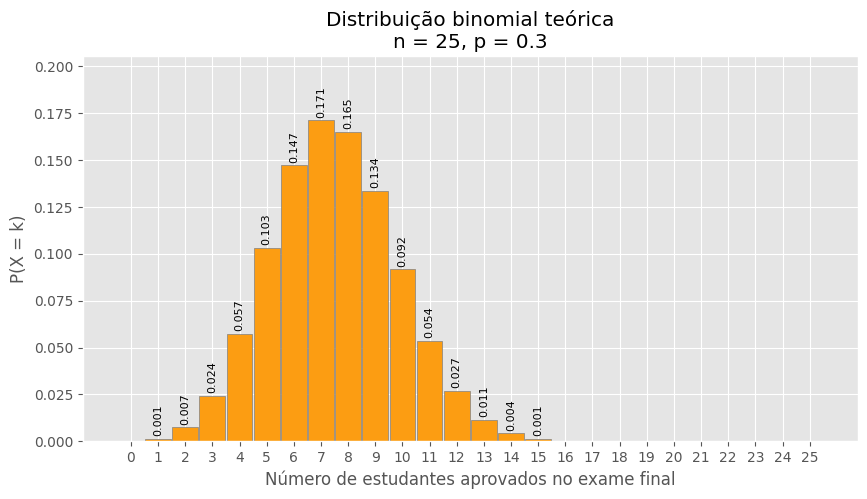

In [221]:
n = 25  # número de estudantes
p = 0.3  # probabilidade de sucesso (aprovação)
k = np.arange(0, n + 1)
pmf = stats.binom.pmf(k, n, p)

plt.figure(figsize=(10, 5))
bars = plt.bar(
    k,
    pmf,
    width=0.95,
    color="#fc9d12",
    edgecolor="grey",
)
rotulos = [f"{valor:.3f}" if valor >= 0.0005 else "" for valor in pmf]
plt.bar_label(bars, labels=rotulos, padding=2, fontsize=8, rotation=90)

plt.xlabel("Número de estudantes aprovados no exame final")
plt.ylabel("P(X = k)")
plt.title("Distribuição binomial teórica\nn = 25, p = 0.3")
plt.xticks(np.arange(0, n + 1, 1))  # eixo x varia de 1 em 1
plt.ylim(0, max(pmf) * 1.2)

plt.show()


**Fig. 5 - Distribuição binomial teórica para n = 25 e p = 0,3.** A figura apresenta a função de massa de probabilidade da variável aleatória binomial $X$, em que $X$ representa o número de estudantes aprovados em 25 ensaios independentes, com probabilidade de aprovação $p = 0{,}3$ em cada ensaio. Fonte: Carubbi, 2026.

Além disso, visualizamos as **probabilidades discutidas acima**: $P(X = 3)$, $P(X = 15)$, $P(X \leq 9)$, $P(X \geq 10)$ (**painel superior**), e a **função de distribuição binomial acumulada correspondente** (**painel inferior**).

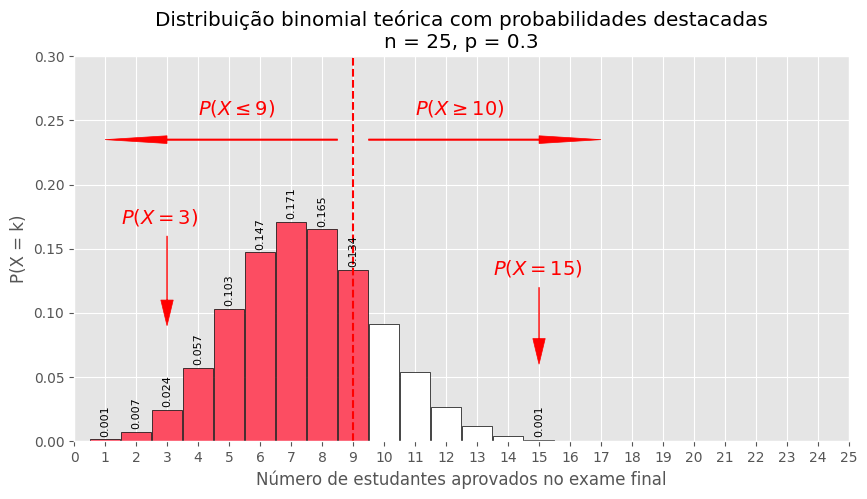

In [222]:
n = 25  # número de estudantes
p = 0.3  # probabilidade de sucesso (aprovação)
k = np.arange(0, n + 1)
pmf = stats.binom.pmf(k, n, p)

plt.figure(figsize=(10, 5))

ax = plt.bar(
    k,
    pmf,
    width=0.95,
    edgecolor="grey",
)

# Destaca as barras conforme a região de probabilidade
for bar, valor_k in zip(ax, k):
    if valor_k <= 9:
        bar.set_color("#fc4d62")
        bar.set_edgecolor("black")
    else:
        bar.set_color("white")
        bar.set_edgecolor("black")

plt.xlabel("Número de estudantes aprovados no exame final")
plt.ylabel("P(X = k)")
plt.title("Distribuição binomial teórica com probabilidades destacadas\nn = 25, p = 0.3")
plt.xticks(np.arange(0, n + 1, 1))

plt.xlim([0, n])
plt.ylim([0, 0.30])
rotulos = [
    f"{valor:.3f}" if (valor_k <= 9 or valor_k == 15) and valor >= 0.0005 else ""
    for valor_k, valor in zip(k, pmf)
]
plt.bar_label(ax, labels=rotulos, padding=2, fontsize=8, rotation=90)

# P[X <= 9]
plt.axvline(x=9, color="red", linestyle="dashed")

plt.arrow(
    8.5,
    0.235,
    -5.5,
    0,
    length_includes_head=False,
    head_width=0.006,
    head_length=2,
    color="red",
)
plt.text(4, 0.255, r"$P(X \leq 9)$", fontsize=14, color="red")

plt.arrow(
    9.5,
    0.235,
    5.5,
    0,
    length_includes_head=False,
    head_width=0.006,
    head_length=2,
    color="red",
)
plt.text(11, 0.255, r"$P(X \geq 10)$", fontsize=14, color="red")

# P[X = 3]
plt.arrow(
    3,
    0.16,
    0,
    -0.07,
    length_includes_head=True,
    head_width=0.4,
    head_length=0.02,
    color="red",
)
plt.text(1.5, 0.17, r"$P(X = 3)$", fontsize=14, color="red")

# P[X = 15]
plt.arrow(
    15,
    0.12,
    0,
    -0.06,
    length_includes_head=True,
    head_width=0.4,
    head_length=0.02,
    color="red",
)
plt.text(13.5, 0.13, r"$P(X = 15)$", fontsize=14, color="red")

plt.show()


**Fig. 6 - Distribuição binomial teórica com regiões de probabilidade destacadas.** A figura apresenta a função de massa de probabilidade da binomial com $n = 25$ e $p = 0{,}3$. As barras destacadas até $k = 9$ representam a região acumulada $P(X \leq 9)$; as barras restantes representam a região complementar $P(X \geq 10)$. As setas também indicam probabilidades pontuais, como $P(X = 3)$ e $P(X = 15)$, reforçando a diferença entre probabilidade exata e probabilidade acumulada. Fonte: Carubbi, 2026.

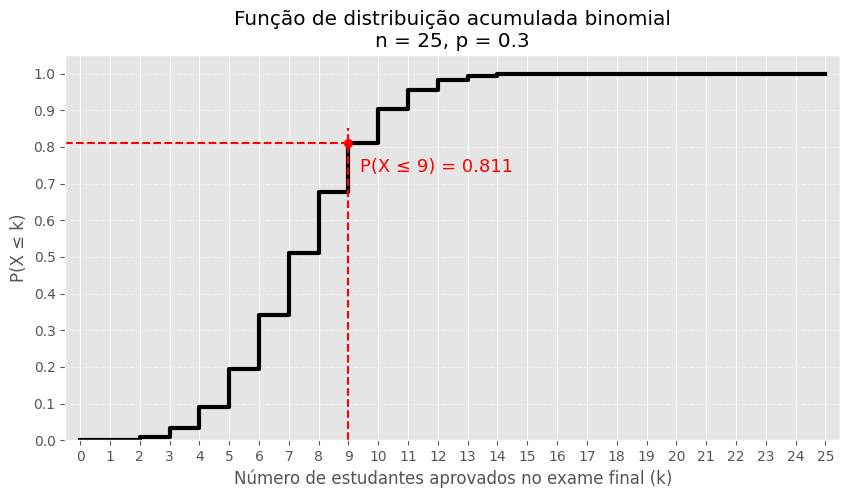

In [223]:
n = 25  # número de estudantes
p = 0.3  # probabilidade de sucesso (aprovação)
k = np.arange(0, n + 1)
cdf = stats.binom.cdf(k, n, p)

k_ref = 9
prob_ref = stats.binom.cdf(k_ref, n, p)

plt.figure(figsize=(10, 5))

plt.step(
    k,
    cdf,
    where="post",
    linewidth=3,
    color="black",
)

plt.scatter(k_ref, prob_ref, color="red", zorder=3)
plt.axvline(x=k_ref, ymax=prob_ref, color="red", linestyle="dashed")
plt.hlines(y=prob_ref, xmin=-0.5, xmax=k_ref, color="red", linestyle="dashed")

plt.text(
    k_ref + 0.4,
    prob_ref - 0.08,
    f"P(X ≤ {k_ref}) = {prob_ref:.3f}",
    fontsize=13,
    color="red",
)

plt.xlabel("Número de estudantes aprovados no exame final (k)")
plt.ylabel("P(X ≤ k)")
plt.title("Função de distribuição acumulada binomial\nn = 25, p = 0.3")
plt.xticks(np.arange(0, n + 1, 1))
plt.xlim(-0.5, n + 0.5)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()


**Fig. 7 - Função de distribuição acumulada binomial para n = 25 e p = 0,3.** A figura apresenta a probabilidade acumulada $P(X \leq k)$ para cada valor possível de $k$. Como a variável aleatória binomial é discreta, a função acumulada é representada em degraus. O ponto destacado mostra que $P(X \leq 9) \approx 0{,}811$. Fonte: Carubbi, 2026.

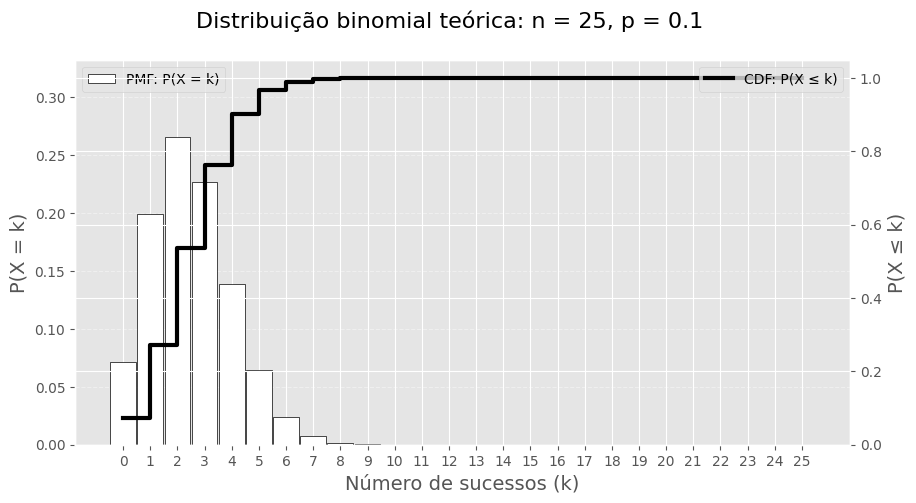

In [224]:
def plot_binomial_pmf_cdf(n, p):
    k = np.arange(0, n + 1)
    pmf = stats.binom.pmf(k, n, p)
    cdf = stats.binom.cdf(k, n, p)

    fig, ax = plt.subplots(figsize=(10, 5))
    fig.suptitle(f"Distribuição binomial teórica: n = {n}, p = {p}", fontsize=16)

    ax.bar(
        k,
        pmf,
        width=0.95,
        color="white",
        edgecolor="black",
        label="PMF: P(X = k)",
    )

    ax.set_xlabel("Número de sucessos (k)", fontsize=14)
    ax.set_xticks(np.arange(0, n + 1, 1))
    ax.set_ylabel("P(X = k)", fontsize=14)
    ax.set_ylim(0, max(pmf) * 1.25)

    ax2 = ax.twinx()
    ax2.step(
        k,
        cdf,
        where="post",
        linewidth=3,
        color="black",
        label="CDF: P(X ≤ k)",
    )

    ax2.set_ylabel("P(X ≤ k)", fontsize=14)
    ax2.set_ylim(0, 1.05)

    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.show()


plot_binomial_pmf_cdf(n=25, p=0.1)


**Fig. 8 - Distribuição binomial teórica e função acumulada para n = 25 e p = 0,1.** A figura combina a função de massa de probabilidade, representada pelas barras, e a função de distribuição acumulada, representada pela curva em degraus. Como $p = 0{,}1$, a maior parte da probabilidade concentra-se em poucos sucessos, próximo da média teórica $np = 2{,}5$, produzindo assimetria à direita. Fonte: Carubbi, 2026.

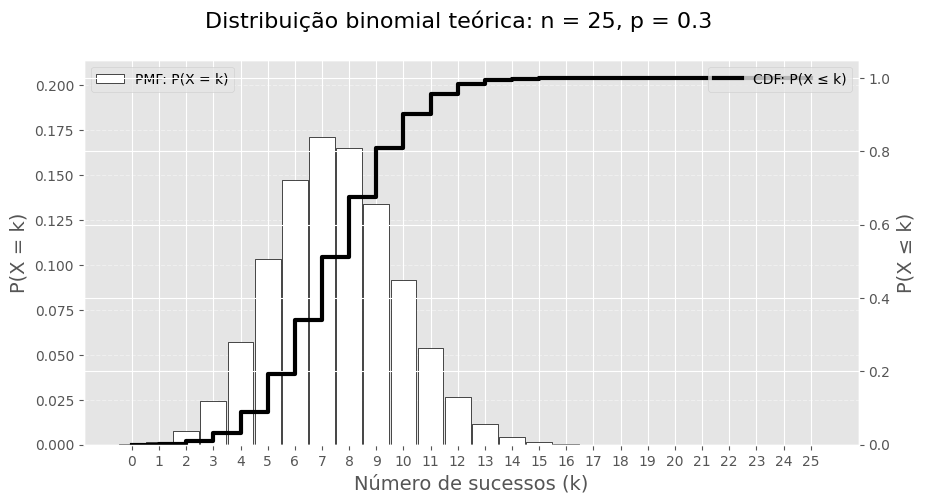

In [225]:
plot_binomial_pmf_cdf(n=25, p=0.3)


**Fig. 9 - Distribuição binomial teórica e função acumulada para n = 25 e p = 0,3.** A figura combina a função de massa de probabilidade e a função de distribuição acumulada para uma binomial com probabilidade de sucesso igual a $0{,}3$. A distribuição concentra maior probabilidade em torno de 7 a 8 sucessos, valor próximo da média teórica $np = 7{,}5$, e apresenta assimetria à direita moderada. Fonte: Carubbi, 2026.

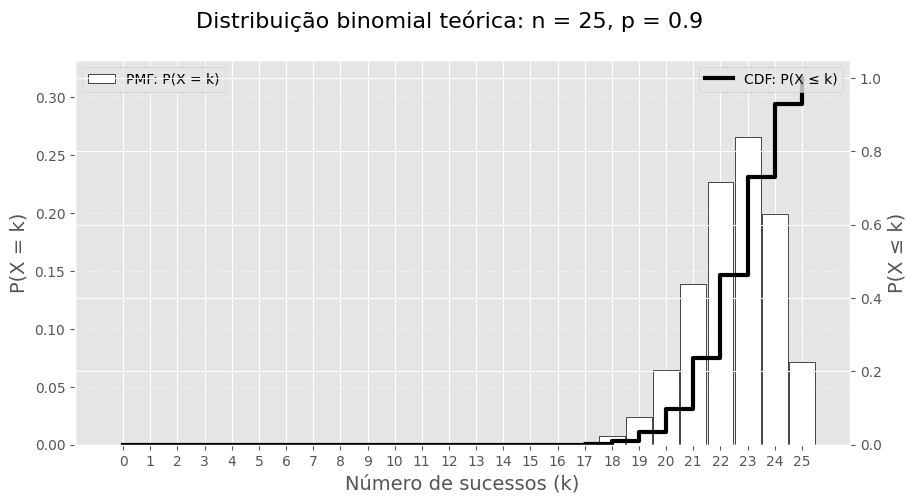

In [226]:
plot_binomial_pmf_cdf(n=25, p=0.9)


**Fig. 10 - Distribuição binomial teórica e função acumulada para n = 25 e p = 0,9.** A figura combina a função de massa de probabilidade e a função de distribuição acumulada para uma binomial com alta probabilidade de sucesso. Com $p = 0{,}9$, a maior parte da probabilidade fica concentrada em muitos sucessos, próximo da média teórica $np = 22{,}5$, produzindo assimetria à esquerda. Fonte: Carubbi, 2026.

### Média e Desvio Padrão de uma Variável Aleatória Binomial

A **média** e o **desvio padrão** de uma variável aleatória binomial com parâmetros  
$n$ e $p$ são dados por:

$$
\mu = n p \tag{16}
$$

e

$$
\sigma = \sqrt{n p (1 - p)}, \tag{17}
$$

respectivamente.

Vamos relembrar o exemplo da seção anterior:  
a probabilidade de aprovação no exame final de estatística é **0,3**.  
Consideramos uma turma com **25 estudantes**.  

A variável aleatória $X$, que representa o **número de estudantes aprovados** no exame,  
segue uma **distribuição binomial** com parâmetros $n = 25$ e $p = 0{,}3$.  
Assim, a média $\mu$ e o desvio padrão $\sigma$ podem ser calculados como segue:

$$
\mu = n p = 25 \times 0{,}3 = 7{,}5 \tag{18}
$$

e

$$
\sigma = \sqrt{n p (1 - p)} = \sqrt{25 \times 0{,}3 \times (1 - 0{,}3)} = 2{,}29 \tag{19}
$$

Como $X$ é uma contagem, seus valores possíveis são inteiros. Já $\mu$, $\mu - \sigma$ e $\mu + \sigma$ são referências teóricas de posição e dispersão; portanto, não precisam ser valores possíveis de $X$.

O gráfico a seguir **visualiza a distribuição binomial teórica** com parâmetros  
$n = 25$ e $p = 0{,}3$, juntamente com sua **média** $\mu$ e os limites de **um desvio padrão** ao redor da média.

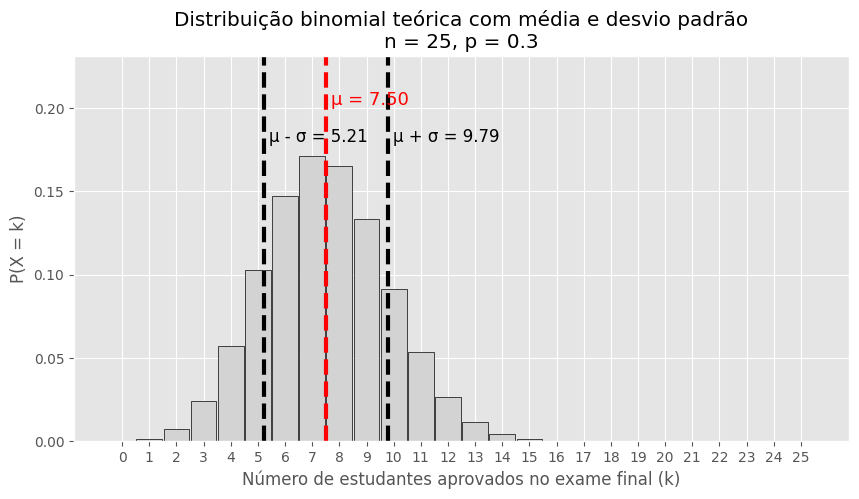

In [227]:
n0 = 25  # número de estudantes
p0 = 0.3  # probabilidade de sucesso (aprovação)

k = np.arange(0, n0 + 1)
pmf = stats.binom.pmf(k, n0, p0)

mu = n0 * p0
sigma = np.sqrt(n0 * p0 * (1 - p0))

plt.figure(figsize=(10, 5))
plt.bar(
    k,
    pmf,
    width=0.95,
    color="lightgrey",
    edgecolor="black",
)

plt.xlabel("Número de estudantes aprovados no exame final (k)")
plt.ylabel("P(X = k)")
plt.ylim([0, max(pmf) * 1.35])
plt.title("Distribuição binomial teórica com média e desvio padrão\nn = 25, p = 0.3")
plt.xticks(np.arange(0, n0 + 1, 1))  # eixo x varia de 1 em 1

plt.axvline(x=mu, color="red", linestyle="dashed", linewidth=3)
plt.axvline(x=mu - sigma, color="black", linestyle="dashed", linewidth=3)
plt.axvline(x=mu + sigma, color="black", linestyle="dashed", linewidth=3)

plt.text(mu + 0.2, max(pmf) * 1.18, f"μ = {mu:.2f}", fontsize=13, color="red")
plt.text(mu - sigma + 0.2, max(pmf) * 1.05, f"μ - σ = {mu - sigma:.2f}", fontsize=12, color="black")
plt.text(mu + sigma + 0.2, max(pmf) * 1.05, f"μ + σ = {mu + sigma:.2f}", fontsize=12, color="black")

plt.show()


**Fig. 11 - Distribuição binomial teórica com média e desvio padrão para n = 25 e p = 0,3.** A figura apresenta a função de massa de probabilidade da binomial com linhas verticais marcando a média $\mu$ e os limites $\mu - \sigma$ e $\mu + \sigma$, usados como referências visuais de centro e dispersão. Como $X$ é uma contagem discreta, essas referências teóricas não precisam coincidir com valores inteiros possíveis de $X$. Fonte: Carubbi, 2026.

### Distribuição Hipergeométrica

A **distribuição hipergeométrica** descreve o número de sucessos obtidos em uma amostra retirada **sem reposição** de uma **população finita**.

A ideia intuitiva é simples: quando retiramos elementos sem devolvê-los à população, a composição da população muda após cada retirada. Por isso, a probabilidade de sucesso pode mudar de uma seleção para a próxima.

Por exemplo, se uma população possui estudantes aprovados e reprovados, e sorteamos alguns estudantes **sem reposição**, a variável aleatória de interesse pode ser:

$$X = \text{número de estudantes aprovados na amostra}$$

Nesse caso, $X$ segue uma **distribuição hipergeométrica**.

### Parâmetros da Distribuição Hipergeométrica

A distribuição hipergeométrica é definida a partir de uma população finita dividida em dois grupos: elementos com o atributo de interesse e elementos sem esse atributo.

Usaremos a seguinte notação:

- $N$: tamanho da população;
- $K$: número de elementos da população com o atributo de interesse;
- $n$: tamanho da amostra retirada sem reposição;
- $X$: número de sucessos observados na amostra.

Assim, $X$ representa uma **contagem**: quantos elementos da amostra pertencem ao grupo de interesse.

### Diferença em Relação à Distribuição Binomial

A diferença central entre a distribuição binomial e a distribuição hipergeométrica está na forma de amostragem.

Na **distribuição binomial**, os ensaios são independentes e a probabilidade de sucesso permanece constante. Isso ocorre, por exemplo, quando a amostragem é feita **com reposição**, ou quando cada tentativa pode ser tratada como independente.

Na **distribuição hipergeométrica**, a amostragem é feita **sem reposição**. Portanto, os ensaios não são independentes, pois o resultado de uma retirada altera a composição da população disponível para as próximas retiradas.

De forma resumida:

| Situação | Distribuição adequada | Ideia principal |
| --- | --- | --- |
| Amostragem com reposição | Binomial | Probabilidade constante e ensaios independentes |
| Amostragem sem reposição em população finita | Hipergeométrica | Probabilidade muda conforme os elementos são retirados |
| Amostragem sem reposição com amostra pequena em relação à população | Binomial como aproximação | A mudança nas probabilidades tende a ser pequena |

### Aproximação Binomial da Distribuição Hipergeométrica

Na prática, a distribuição hipergeométrica pode ser aproximada por uma distribuição binomial quando a amostra é pequena em relação ao tamanho da população.

Como regra prática, quando o tamanho da amostra não excede cerca de **5% do tamanho da população**, a diferença entre amostrar com reposição e sem reposição costuma ser pequena (**Weiss, 2010**).

Nessa situação, se a proporção populacional de sucessos é

$$p = \frac{K}{N},$$

podemos aproximar

$$X \sim \text{Hipergeométrica}(N, K, n)$$

por

$$X \sim \text{Binomial}(n, p).$$

Essa aproximação não significa que as duas distribuições sejam iguais. Ela significa apenas que, quando a fração amostral é pequena, a alteração nas probabilidades ao longo das retiradas tende a ter pouco impacto nos resultados.


### Comparação Explícita entre Hipergeométrica e Binomial

Para visualizar a aproximação, vamos comparar as duas distribuições em uma mesma situação.

Suponha uma população com $N = 100$ estudantes, dos quais $K = 30$ foram aprovados em uma avaliação diagnóstica. Assim, a proporção populacional de estudantes aprovados é:

$$p = \frac{K}{N} = \frac{30}{100} = 0{,}3$$

Se retirarmos uma amostra de tamanho $n = 5$ sem reposição, $X$ representa o **número de estudantes aprovados na amostra**. A distribuição exata de $X$ é hipergeométrica. Como $n/N = 5/100 = 5\%$, também podemos compará-la com a aproximação binomial $X \sim \text{Binomial}(5; 0{,}3)$.


In [228]:
N_pop = 100      # tamanho da população
K_sucessos = 30  # número de estudantes aprovados na população
n_amostra = 5    # tamanho da amostra
p = K_sucessos / N_pop

k = np.arange(0, n_amostra + 1)

comparacao = pd.DataFrame({
    "k": k,
    "Hipergeométrica P(X = k)": stats.hypergeom.pmf(
        k,
        M=N_pop,
        n=K_sucessos,
        N=n_amostra,
    ),
    "Binomial P(X = k)": stats.binom.pmf(k, n_amostra, p),
})

comparacao["Diferença absoluta"] = (
    comparacao["Hipergeométrica P(X = k)"] - comparacao["Binomial P(X = k)"]
).abs()

print(comparacao, "\n")

print(f"Fração amostral: n/N = {n_amostra}/{N_pop} = {n_amostra / N_pop:.1%}")
print("Como a fração amostral é pequena, as probabilidades ficam próximas, mas não idênticas.")


   k  Hipergeométrica P(X = k)  Binomial P(X = k)  Diferença absoluta
0  0                  0.160757            0.16807            0.007313
1  1                  0.365357            0.36015            0.005207
2  2                  0.316280            0.30870            0.007580
3  3                  0.130233            0.13230            0.002067
4  4                  0.025480            0.02835            0.002870
5  5                  0.001893            0.00243            0.000537 

Fração amostral: n/N = 5/100 = 5.0%
Como a fração amostral é pequena, as probabilidades ficam próximas, mas não idênticas.


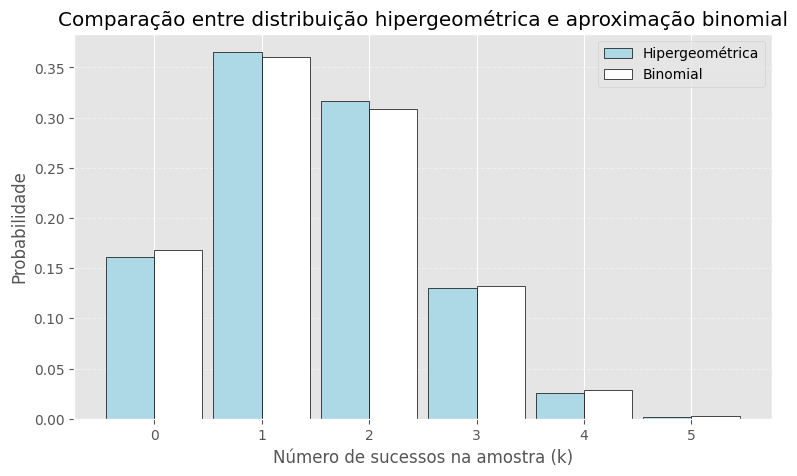

In [229]:
largura = 0.45

plt.figure(figsize=(9, 5))
plt.bar(
    k - largura / 2,
    comparacao["Hipergeométrica P(X = k)"],
    width=largura,
    color="lightblue",
    edgecolor="black",
    label="Hipergeométrica",
)
plt.bar(
    k + largura / 2,
    comparacao["Binomial P(X = k)"],
    width=largura,
    color="white",
    edgecolor="black",
    label="Binomial",
)

plt.title("Comparação entre distribuição hipergeométrica e aproximação binomial")
plt.xlabel("Número de sucessos na amostra (k)")
plt.ylabel("Probabilidade")
plt.xticks(k)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


A comparação mostra que a distribuição binomial pode ficar muito próxima da hipergeométrica quando a amostra é pequena em relação à população. Mesmo assim, a distribuição exata continua sendo a hipergeométrica, pois a amostragem foi feita sem reposição.


## Distribuição de Poisson

Vamos apresentar a distribuição de Poisson por meio de um exemplo.  

O exemplo usa a enchente de 100 anos, conceito amplamente utilizado em engenharia para o planejamento de medidas de controle de enchentes.

A função de massa de probabilidade de uma variável aleatória de Poisson é dada por:

$$
P(X = x) = e^{-\lambda} \frac{\lambda^x}{x!}, \quad x = 0, 1, 2, \ldots, \tag{20}
$$

em que $\lambda$ é um número real positivo que representa o **número médio de ocorrências** em um intervalo fixo de tempo ou espaço, e $e \approx 2{,}718$ é uma constante matemática, chamada **número de Euler**. Assim como $\pi$ aparece com frequência em problemas de geometria, $e$ aparece em problemas envolvendo crescimento, decaimento e taxas de ocorrência ao longo do tempo.

A enchente de 100 anos é um termo abreviado para uma enchente com **probabilidade anual de excedência de 1%** e **intervalo médio de recorrência de 100 anos**. O termo pode causar confusão, pois é comum interpretá-lo como se a enchente ocorresse exatamente uma vez a cada 100 anos.  

Essa interpretação está incorreta. Uma probabilidade anual de excedência de 1% significa que, em qualquer ano específico, há probabilidade de **0,01** de ocorrer uma enchente de magnitude correspondente à chamada enchente de 100 anos.

No contexto de uma **distribuição de Poisson**, o valor esperado do número de enchentes de 100 anos em um intervalo de 100 anos é $E(X) = \lambda = 100 \times 0,01 = 1$.  

Consequentemente, a variável aleatória de Poisson $X$ representa o número de ocorrências desse evento no período analisado. Dependendo da pergunta de interesse, podemos calcular diferentes probabilidades.

Podemos estar interessados na **probabilidade de que nenhuma enchente desse tipo ocorra** durante o intervalo de 100 anos, $P(X = 0)$; na **probabilidade de que ocorra exatamente uma enchente**, $P(X = 1)$; ou ainda na **probabilidade de que ocorram duas ou mais enchentes**, $P(X \geq 2)$.  

Substituindo esses valores na equação acima, obtemos:

$$
\lambda = 1, \quad x = 0, 1, 2, \ldots \tag{21}
$$

$$
P(X = 0) = e^{-1} \frac{1^0}{0!}, \quad \text{para } x = 0 \tag{22}
$$

$$
P(X = 1) = e^{-1} \frac{1^1}{1!}, \quad \text{para } x = 1 \tag{23}
$$

$$
P(X \geq 2) = 1 - P(X \leq 1) = 1 - [P(X = 0) + P(X = 1)] \tag{24}
$$

Usaremos o **Python** para fazer os cálculos.  

Utilizaremos a distribuição **`poisson`**, disponível no módulo **`scipy.stats`**. Essa distribuição possui diferentes métodos; use **`help()`** para consultar mais informações.

**Nota:**  
A função **`poisson.pmf(k, mu)`** recebe $\lambda$ pelo argumento **mu**, que representa o parâmetro da distribuição.

In [230]:
def poisson_pmf(k, lam):
    """
    Calcula a Função de Massa de Probabilidade (PMF) da distribuição de Poisson.

    Parâmetros:
        k (int): número de ocorrências
        lam (float): valor esperado (λ)

    Retorna:
        float: probabilidade P(X = k)
    """
    from math import exp, factorial

    return (exp(-lam) * lam**k) / factorial(k)


lambda_pois = 1  # número médio de enchentes em 100 anos
k = [0, 1]  # números de enchentes de interesse

prob_zero_manual = poisson_pmf(k[0], lambda_pois)
prob_zero_scipy = stats.poisson.pmf(k[0], mu=lambda_pois)

print(f"P(X = {k[0]}) calculada pela fórmula = {prob_zero_manual:.4f} ({prob_zero_manual:.1%})")
print(f"P(X = {k[0]}) calculada pelo SciPy = {prob_zero_scipy:.4f} ({prob_zero_scipy:.1%})")

P(X = 0) calculada pela fórmula = 0.3679 (36.8%)
P(X = 0) calculada pelo SciPy = 0.3679 (36.8%)


In [231]:
prob_um = stats.poisson.pmf(k[1], mu=lambda_pois)

print(f"P(X = {k[1]}) para X ~ Poisson(λ = {lambda_pois})")
print(f"Probabilidade de exatamente uma enchente em 100 anos = {prob_um:.4f} ({prob_um:.1%})")

P(X = 1) para X ~ Poisson(λ = 1)
Probabilidade de exatamente uma enchente em 100 anos = 0.3679 (36.8%)


Lembrete: ao calcular probabilidades acumuladas com **`cdf`**, não há argumento adicional para escolher a cauda.  

O **Python** calcula, por padrão, a **cauda esquerda**, isto é, $P(X \leq x)$.  

Para calcular a **cauda direita**, é necessário usar o complemento adequado. Por exemplo, `1 - poisson.cdf(x, mu)` calcula $P(X > x)$.

In [232]:
def poisson_cdf(k, lam):
    """
    Calcula a Função de Distribuição Acumulada (CDF) da distribuição de Poisson.

    Parâmetros:
        k (int): número de ocorrências até o qual acumular
        lam (float): valor esperado (λ)

    Retorna:
        float: probabilidade acumulada P(X ≤ k)
    """
    from math import exp, factorial

    cdf = 0
    for i in range(0, k + 1):
        cdf += (exp(-lam) * lam**i) / factorial(i)
    return cdf

prob_ate_um = stats.poisson.cdf(k[1], mu=lambda_pois)
prob_duas_ou_mais = 1 - prob_ate_um

print(f"P(X <= {k[1]}) = {prob_ate_um:.4f} ({prob_ate_um:.1%})")
print(f"P(X >= {k[1] + 1}) = 1 - P(X <= {k[1]})")
print(f"Probabilidade de duas ou mais enchentes em 100 anos = {prob_duas_ou_mais:.4f} ({prob_duas_ou_mais:.1%})")

P(X <= 1) = 0.7358 (73.6%)
P(X >= 2) = 1 - P(X <= 1)
Probabilidade de duas ou mais enchentes em 100 anos = 0.2642 (26.4%)


Os resultados indicam que a **probabilidade de que nenhuma enchente** de magnitude correspondente a uma enchente de 100 anos ocorra durante um período de 100 anos, $P(X = 0)$, é **0,36**. Esse valor é aproximadamente igual à probabilidade de ocorrer **exatamente uma enchente**, $P(X = 1)$.  

A probabilidade de que **duas ou mais** dessas enchentes ocorram durante o intervalo de 100 anos, $P(X \geq 2)$, é aproximadamente **0,264**, ou seja, **26,4%**.

Como verificação de coerência, somamos as probabilidades $P(X = 0)$, $P(X = 1)$ e $P(X \geq 2)$; a soma deve resultar em **1**.

In [233]:
soma_probabilidades = prob_zero_scipy + prob_um + prob_duas_ou_mais

print("Verificação de coerência:")
print(f"P(X = 0) + P(X = 1) + P(X >= 2) = {soma_probabilidades:.4f}")

Verificação de coerência:
P(X = 0) + P(X = 1) + P(X >= 2) = 1.0000


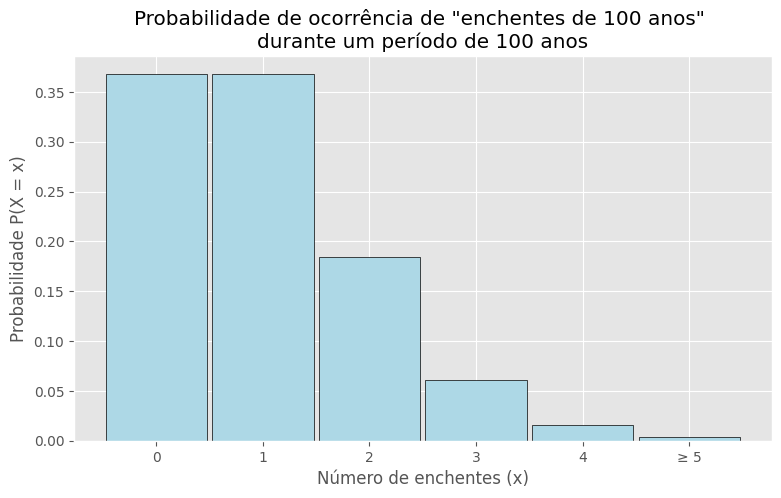

In [234]:
lambda_pois = 1  # número médio de enchentes em 100 anos
out = []
k = np.arange(0, 6)

out.append(stats.poisson.pmf(k=k[0], mu=lambda_pois))
out.append(stats.poisson.pmf(k=k[1], mu=lambda_pois))
out.append(stats.poisson.pmf(k=k[2], mu=lambda_pois))
out.append(stats.poisson.pmf(k=k[3], mu=lambda_pois))
out.append(stats.poisson.pmf(k=k[4], mu=lambda_pois))
out.append(1 - stats.poisson.cdf(k=4, mu=lambda_pois))  # P(X ≥ 5) = 1 - P(X ≤ 4)

# Gráfico
plt.figure(figsize=(9, 5))
plt.bar(k, out, width=0.95, color="lightblue", edgecolor="black")
plt.xlabel("Número de enchentes (x)")
plt.ylabel("Probabilidade P(X = x)")
plt.title('Probabilidade de ocorrência de "enchentes de 100 anos" \ndurante um período de 100 anos')
plt.xticks(k, (["0", "1", "2", "3", "4", "≥ 5"]))

plt.show()


**Fig. 12 - Probabilidade de ocorrência de enchentes de 100 anos em um período de 100 anos.** A figura apresenta as probabilidades para diferentes números de enchentes em 100 anos, incluindo a categoria de cinco ou mais ocorrências. O gráfico mostra que um evento chamado de enchente de 100 anos não significa ocorrência garantida exatamente uma vez em 100 anos, mas sim uma probabilidade anual associada ao fenômeno. Fonte: Carubbi, 2026.

O exemplo da enchente ilustra a ideia geral da **distribuição de Poisson**: modelar uma contagem de ocorrências em um intervalo fixo de tempo ou espaço.

A variável aleatória $X$ representa o **número de ocorrências** no intervalo analisado. Como se trata de uma contagem, seus valores possíveis são os números inteiros não negativos:

$$x = 0, 1, 2, \ldots$$

A distribuição é identificada por um único parâmetro, $\lambda$, que representa o **número médio de ocorrências** no intervalo. Por exemplo, se um evento ocorre em média 10 vezes por segundo, em 60 segundos o valor esperado é $\lambda = 600$.

Esse parâmetro deve sempre estar ligado ao intervalo considerado. Mudar o intervalo muda o valor de $\lambda$.


### Forma, Média e Desvio Padrão de uma Distribuição de Poisson

Para valores pequenos de $\lambda$, a distribuição de Poisson costuma ser **assimétrica à direita**. Não há uma fronteira matemática rígida para definir quando $\lambda$ é pequeno, mas, como regra didática, valores abaixo de aproximadamente 5 tendem a apresentar assimetria à direita bem visível. À medida que $\lambda$ aumenta, especialmente a partir de valores em torno de 10, sua forma se torna progressivamente mais próxima de uma distribuição simétrica.  

A **média** ($\mu$) e o **desvio padrão** ($\sigma$) de uma variável aleatória de Poisson  
com parâmetro $\lambda$ são dados por:

$$
\mu = \lambda \tag{26}
$$

e

$$
\sigma = \sqrt{\lambda} \tag{27}
$$

### Aproximação de Poisson à Distribuição Binomial

Em situações em que $n$ é **grande** e $p$ é **muito pequeno**, a **distribuição de Poisson** pode ser usada para **aproximar a distribuição binomial**.  

Recorde-se da distribuição de probabilidade binomial:

$$
P(X = x) = \binom{n}{x} p^x (1 - p)^{n - x}, \quad x = 0, 1, 2, \ldots, n. \tag{28}
$$

Nessa aproximação, substituímos os dois parâmetros da binomial, $n$ e $p$, por um único parâmetro da Poisson:

$$
\lambda = np \tag{29}
$$

Vamos comparar uma variável aleatória binomial com parâmetros $n = 100$ e $p = 0{,}01$ com uma variável aleatória de Poisson com $\lambda = 100 \times 0{,}01 = 1$.

A aproximação será boa se as probabilidades pontuais das duas distribuições forem parecidas para os mesmos valores de $k$.

In [235]:
n = 100
p = 0.01
lambda_pois = n * p

k = np.arange(0, 8)

comparacao = pd.DataFrame({
    "k": k,
    "Binomial P(X = k)": stats.binom.pmf(k, n, p),
    "Poisson P(Y = k)": stats.poisson.pmf(k, mu=lambda_pois),
})

comparacao["Diferença absoluta"] = (
    comparacao["Binomial P(X = k)"] - comparacao["Poisson P(Y = k)"]
).abs()

print(comparacao)

   k  Binomial P(X = k)  Poisson P(Y = k)  Diferença absoluta
0  0           0.366032          0.367879            0.001847
1  1           0.369730          0.367879            0.001850
2  2           0.184865          0.183940            0.000925
3  3           0.060999          0.061313            0.000314
4  4           0.014942          0.015328            0.000387
5  5           0.002898          0.003066            0.000168
6  6           0.000463          0.000511            0.000047
7  7           0.000063          0.000073            0.000010


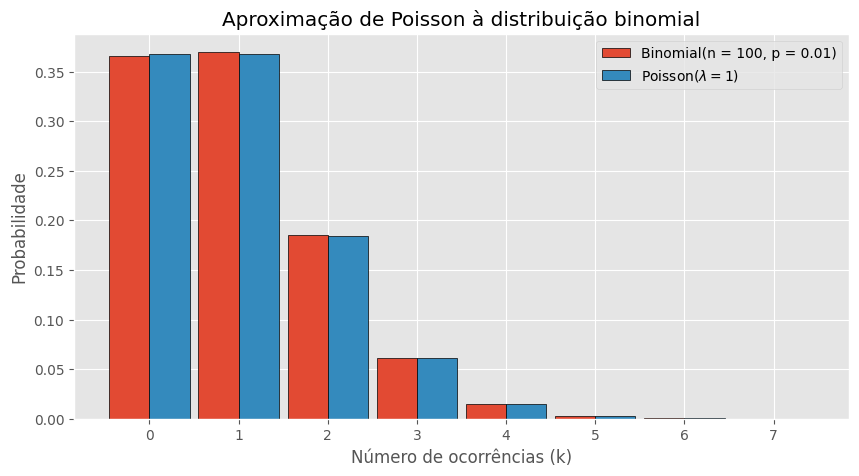

In [236]:
plt.figure(figsize=(10, 5))

largura = 0.45

plt.bar(
    k - largura / 2,
    stats.binom.pmf(k, n, p),
    width=largura,
    label="Binomial(n = 100, p = 0.01)",
    edgecolor="black",
)

plt.bar(
    k + largura / 2,
    stats.poisson.pmf(k, mu=lambda_pois),
    width=largura,
    label=r"Poisson($\lambda = 1$)",
    edgecolor="black",
)

plt.xlabel("Número de ocorrências (k)")
plt.ylabel("Probabilidade")
plt.title("Aproximação de Poisson à distribuição binomial")
plt.xticks(k)
plt.legend()
plt.show()

A tabela e o gráfico mostram que as probabilidades da distribuição binomial e da distribuição de Poisson são muito próximas neste caso.

Isso ocorre porque temos muitos ensaios ($n = 100$), mas a probabilidade de sucesso em cada ensaio é pequena ($p = 0{,}01$). Assim, em vez de trabalhar diretamente com $n$ e $p$, podemos usar a taxa média de ocorrências $\lambda = np = 1$.

A aproximação não significa que as distribuições são idênticas, mas que, para fins práticos, a Poisson pode representar bem a binomial quando os eventos são raros e o número de oportunidades é grande.

In [237]:
lambda_pois = 2.5  # número médio de ocorrências

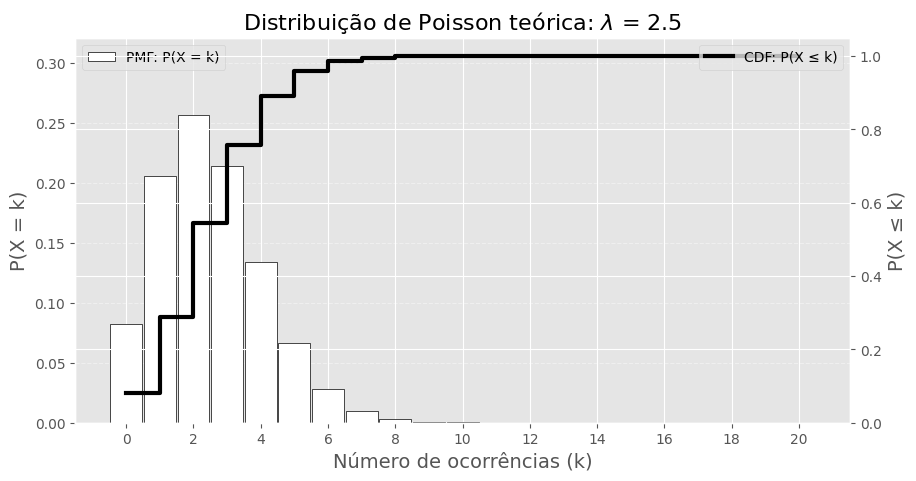

In [238]:
def plot_poisson_pmf_cdf(lambda_pois, k_max=30):
    k = np.arange(0, k_max + 1)
    pmf = stats.poisson.pmf(k, mu=lambda_pois)
    cdf = stats.poisson.cdf(k, mu=lambda_pois)

    fig, ax = plt.subplots(figsize=(10, 5))
    plt.title(fr"Distribuição de Poisson teórica: $\lambda$ = {lambda_pois}", fontsize=16)

    ax.bar(
        k,
        pmf,
        width=0.95,
        color="white",
        edgecolor="black",
        label="PMF: P(X = k)",
    )

    ax.set_xlabel("Número de ocorrências (k)", fontsize=14)
    ax.set_ylabel("P(X = k)", fontsize=14)
    ax.set_xticks(range(0, k_max + 1, 2))
    ax.set_ylim(0, max(pmf) * 1.25)

    ax2 = ax.twinx()

    ax2.step(
        k,
        cdf,
        where="post",
        linewidth=3,
        color="black",
        label="CDF: P(X ≤ k)",
    )

    ax2.set_ylabel("P(X ≤ k)", fontsize=14)
    ax2.set_ylim(0, 1.05)

    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.show()

plot_poisson_pmf_cdf(lambda_pois=2.5, k_max=20)

**Fig. 13 - Distribuição de Poisson teórica e probabilidade acumulada para $\lambda = 2,5$.** A figura combina a função de massa de probabilidade (PMF), representada pelas barras, com a função de distribuição acumulada (CDF), representada pela linha em degraus. A distribuição concentra maior probabilidade em contagens próximas de $\lambda$, enquanto a curva acumulada mostra a probabilidade de observar até determinado número de ocorrências. Fonte: Carubbi, 2026.

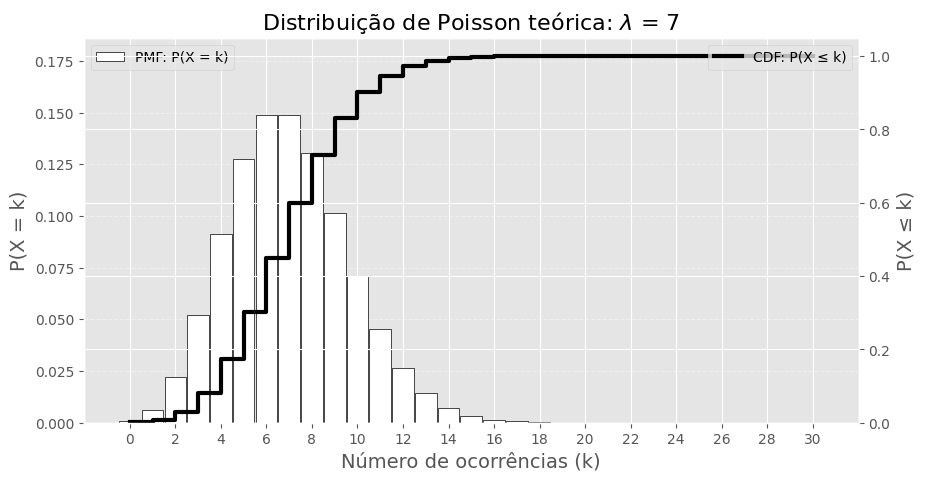

In [239]:
plot_poisson_pmf_cdf(lambda_pois=7, k_max=30)

**Fig. 14 - Distribuição de Poisson teórica e probabilidade acumulada para $\lambda = 7$.** A figura apresenta a função de massa de probabilidade (PMF), representada pelas barras, e a função de distribuição acumulada (CDF), representada pela linha em degraus. Em comparação com valores menores de $\lambda$, a distribuição fica menos assimétrica à direita e concentra maior probabilidade em torno de contagens próximas de 7. Fonte: Carubbi, 2026.